## Task 1: Load and Understand the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("utility_late_payment_dataset.csv")

df.head()

,account_id,customer_age,age_group,gender,region,household_type,plan_type,payment_method,monthly_bill_amount,average_usage_kwh,months_as_customer,previous_late_payments,autopay_enabled,support_calls_last_6m,paperless_billing,income_estimate,late_payment_next_month
0,U0001,33,26-35,Female,East,Shared,Fixed,Bank Transfer,305.04,989,84,4,No,0,Yes,100162.0,1
1,U0002,57,51+,Female,West,Family,Variable,Bank Transfer,118.85,1850,1,4,No,2,No,32940.0,1
2,U0003,61,51+,Female,West,Couple,Green Energy,Credit Card,253.08,775,49,3,Yes,3,No,84136.0,0
3,U0004,61,51+,Female,South,Couple,Green Energy,Debit,139.03,1839,64,0,Yes,3,No,109059.0,0
4,U0005,72,51+,Male,North,Shared,Fixed,Bank Transfer,189.71,336,86,0,No,0,Yes,58827.0,1


In [2]:
df.shape

(370, 17)

In [3]:
df.columns

Index(['account_id', 'customer_age', 'age_group', 'gender', 'region',
       'household_type', 'plan_type', 'payment_method', 'monthly_bill_amount',
       'average_usage_kwh', 'months_as_customer', 'previous_late_payments',
       'autopay_enabled', 'support_calls_last_6m', 'paperless_billing',
       'income_estimate', 'late_payment_next_month'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   account_id               370 non-null    object 
 1   customer_age             370 non-null    int64  
 2   age_group                370 non-null    object 
 3   gender                   370 non-null    object 
 4   region                   370 non-null    object 
 5   household_type           370 non-null    object 
 6   plan_type                370 non-null    object 
 7   payment_method           370 non-null    object 
 8   monthly_bill_amount      368 non-null    float64
 9   average_usage_kwh        370 non-null    int64  
 10  months_as_customer       370 non-null    int64  
 11  previous_late_payments   370 non-null    int64  
 12  autopay_enabled          370 non-null    object 
 13  support_calls_last_6m    370 non-null    int64  
 14  paperless_billing        3

In [5]:
df.isnull().sum()

account_id                 0
customer_age               0
age_group                  0
gender                     0
region                     0
household_type             0
plan_type                  0
payment_method             0
monthly_bill_amount        2
average_usage_kwh          0
months_as_customer         0
previous_late_payments     0
autopay_enabled            0
support_calls_last_6m      0
paperless_billing          0
income_estimate            5
late_payment_next_month    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['late_payment_next_month'].value_counts()

late_payment_next_month
1    218
0    152
Name: count, dtype: int64

In [8]:
df['late_payment_next_month'].value_counts(normalize=True) * 100

late_payment_next_month
1    58.918919
0    41.081081
Name: proportion, dtype: float64

## Task 2: Define Features and Target Variable

In [9]:
y = df["late_payment_next_month"]

X = df.drop(columns=["account_id", "late_payment_next_month"])

X.head()

,customer_age,age_group,gender,region,household_type,plan_type,payment_method,monthly_bill_amount,average_usage_kwh,months_as_customer,previous_late_payments,autopay_enabled,support_calls_last_6m,paperless_billing,income_estimate
0,33,26-35,Female,East,Shared,Fixed,Bank Transfer,305.04,989,84,4,No,0,Yes,100162.0
1,57,51+,Female,West,Family,Variable,Bank Transfer,118.85,1850,1,4,No,2,No,32940.0
2,61,51+,Female,West,Couple,Green Energy,Credit Card,253.08,775,49,3,Yes,3,No,84136.0
3,61,51+,Female,South,Couple,Green Energy,Debit,139.03,1839,64,0,Yes,3,No,109059.0
4,72,51+,Male,North,Shared,Fixed,Bank Transfer,189.71,336,86,0,No,0,Yes,58827.0


In [10]:
fairness_columns = df[["gender", "age_group", "region"]]

X = X.drop(columns=["gender", "age_group", "region"])

X.head()

,customer_age,household_type,plan_type,payment_method,monthly_bill_amount,average_usage_kwh,months_as_customer,previous_late_payments,autopay_enabled,support_calls_last_6m,paperless_billing,income_estimate
0,33,Shared,Fixed,Bank Transfer,305.04,989,84,4,No,0,Yes,100162.0
1,57,Family,Variable,Bank Transfer,118.85,1850,1,4,No,2,No,32940.0
2,61,Couple,Green Energy,Credit Card,253.08,775,49,3,Yes,3,No,84136.0
3,61,Couple,Green Energy,Debit,139.03,1839,64,0,Yes,3,No,109059.0
4,72,Shared,Fixed,Bank Transfer,189.71,336,86,0,No,0,Yes,58827.0


## Task 3: Data Preprocessing

In [11]:
df.isnull().sum()

account_id                 0
customer_age               0
age_group                  0
gender                     0
region                     0
household_type             0
plan_type                  0
payment_method             0
monthly_bill_amount        2
average_usage_kwh          0
months_as_customer         0
previous_late_payments     0
autopay_enabled            0
support_calls_last_6m      0
paperless_billing          0
income_estimate            5
late_payment_next_month    0
dtype: int64

In [12]:
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

print(categorical_columns)

print(numerical_columns)

Index(['household_type', 'plan_type', 'payment_method', 'autopay_enabled',
       'paperless_billing'],
      dtype='object')
Index(['customer_age', 'monthly_bill_amount', 'average_usage_kwh',
       'months_as_customer', 'previous_late_payments', 'support_calls_last_6m',
       'income_estimate'],
      dtype='object')


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


Preprocessing is necessary because machine learning models cannot handle missing values or categorical text data directly.
Missing values are imputed and categorical variables are converted into numerical form using one-hot encoding.

In [14]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,customer_age,monthly_bill_amount,average_usage_kwh,months_as_customer,previous_late_payments,support_calls_last_6m,income_estimate,household_type_Family,household_type_Shared,household_type_Single,plan_type_Green Energy,plan_type_Variable,payment_method_Cash,payment_method_Credit Card,payment_method_Debit,autopay_enabled_Yes,paperless_billing_Yes
0,33,305.04,989,84,4,0,100162.0,False,True,False,False,False,False,False,False,False,True
1,57,118.85,1850,1,4,2,32940.0,True,False,False,False,True,False,False,False,False,False
2,61,253.08,775,49,3,3,84136.0,False,False,False,True,False,False,True,False,True,False
3,61,139.03,1839,64,0,3,109059.0,False,False,False,True,False,False,False,True,True,False
4,72,189.71,336,86,0,0,58827.0,False,True,False,False,False,False,False,False,False,True


## Task 4: Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

fairness_columns = df[["gender", "age_group", "region"]]

X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
    X,
    y,
    fairness_columns,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("fairness_train shape:", fairness_train.shape)
print("fairness_test shape:", fairness_test.shape)

X_train shape: (296, 17)
X_test shape: (74, 17)
y_train shape: (296,)
y_test shape: (74,)
fairness_train shape: (296, 3)
fairness_test shape: (74, 3)


Training data is used to teach the model patterns within the dataset.
Testing data is held back and used to evaluate how well the model performs on unseen data.

## Task 5: Train a Classification Model

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [20]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,0,1
6,1,1
7,1,1
8,1,0
9,0,0


The model learns patterns that distinguish customers likely to make late payments from those likely to pay on time.
The comparison table allows us to inspect whether individual predictions are correct.

## Task 6: Evaluate the Model

In [21]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)

evaluation_results = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [train_accuracy, test_accuracy]
})

evaluation_results

,Dataset,Accuracy
0,Training Data,0.827703
1,Testing Data,0.662162


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_test_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred, zero_division=0)

recall = recall_score(y_test, y_test_pred, zero_division=0)

f1 = f1_score(y_test, y_test_pred, zero_division=0)

metrics_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_results

,Metric,Score
0,Accuracy,0.662162
1,Precision,0.711111
2,Recall,0.727273
3,F1-Score,0.719101


### Accuracy (66.2%)

Accuracy measures the overall percentage of correct predictions made by the model. An accuracy of 66.2% means that the model correctly predicted whether a customer would make a late payment or not for approximately two-thirds of the customers in the test dataset.

### Precision (71.1%)

Precision measures how often the model is correct when it predicts that a customer will make a late payment. A precision score of 71.1% means that about 71 out of every 100 customers predicted as late payers actually became late payers.

### Recall (72.7%)

Recall measures how many actual late-payment customers were successfully identified by the model. A recall score of 72.7% means that the model correctly detected about 73 out of every 100 customers who actually made a late payment.

### F1-Score (71.9%)

The F1-score combines precision and recall into a single metric. A score of 71.9% indicates a reasonable balance between correctly identifying late-payment customers and avoiding incorrect late-payment predictions.

### Most Important Metric for This Business Problem

For this utility late-payment prediction problem, Recall is the most important metric.
The goal of the model is to identify customers who are likely to make late payments so that the company can take preventive actions, such as sending reminders or offering payment assistance. If the model fails to identify a customer who will actually make a late payment (a false negative), the company may lose revenue and miss an opportunity to reduce payment risk.
The model achieved a recall of 72.7%, meaning it successfully identified most customers who were at risk of making a late payment. Therefore, recall is the most critical metric because missing high-risk customers could have a greater financial impact than incorrectly flagging some low-risk customers.

## Task 7: Confusion Matrix

In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

cm_table = pd.DataFrame(
    cm,
    index=["Actual On-Time Payment (0)", "Actual Late Payment (1)"],
    columns=["Predicted On-Time Payment (0)", "Predicted Late Payment (1)"]
)

cm_table

,Predicted On-Time Payment (0),Predicted Late Payment (1)
Actual On-Time Payment (0),17,13
Actual Late Payment (1),12,32


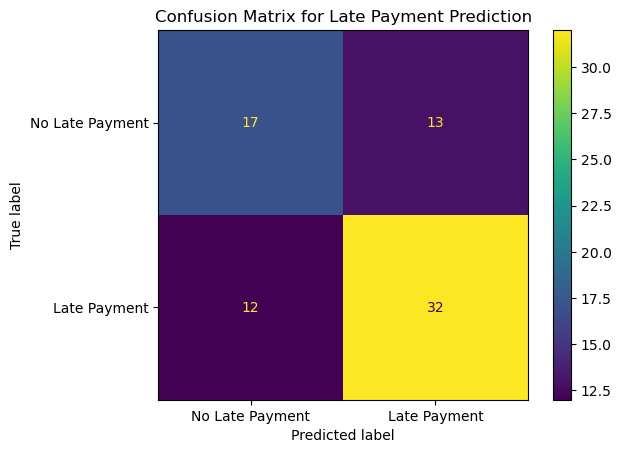

In [24]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Late Payment", "Late Payment"]
)

display.plot()

plt.title("Confusion Matrix for Late Payment Prediction")

plt.show()


* True Negatives (TN) = 17
* False Positives (FP) = 13
* False Negatives (FN) = 12
* True Positives (TP) = 32

### Main Observation

The most common error type in this model is False Positive, with 13 cases, followed closely by False Negative, with 12 cases. This indicates that the model is slightly more likely to predict a late payment for customers who actually pay on time.

### False Positives (FP = 13)

A false positive occurs when the model predicts that a customer will make a late payment, but the customer actually pays on time. In this dataset, 13 customers were incorrectly identified as being at risk of late payment. As a result, the utility company may send unnecessary payment reminders, warnings, or follow-up communications to customers who would have paid on time. This could increase operational costs and potentially reduce customer satisfaction because some customers may feel they are being contacted unnecessarily.

### False Negatives (FN = 12)

A false negative occurs when the model predicts that a customer will pay on time, but the customer actually makes a late payment. In this dataset, 12 customers who eventually made late payments were missed by the model. This means the utility company would not take any preventive action, such as sending reminders or offering payment assistance, before the payment becomes overdue. As a result, the company may experience delayed payments and increased collection efforts.

### Which Type of Error Is More Serious?

For this utility late-payment prediction problem, false negatives are more serious. When a false negative occurs, the company fails to identify a customer who is actually at risk of making a late payment. This may result in delayed revenue collection, increased collection costs, and a higher risk of unpaid bills. Although false positives can lead to unnecessary reminders being sent to customers who would have paid on time, the financial impact is generally lower than missing customers who are likely to make late payments. Therefore, reducing false negatives should be a priority because identifying high-risk customers early allows the utility company to take proactive actions and reduce payment risk.


## Task 8: Error Analysis

In [25]:
y_test_pred = model.predict(X_test)

error_analysis = pd.DataFrame({"Account ID": df.loc[y_test.index, "account_id"].values, "Actual Late Payment": y_test.values, "Predicted Late Payment": y_test_pred
})

error_analysis["Correct Prediction"] = (
    error_analysis["Actual Late Payment"] ==
    error_analysis["Predicted Late Payment"]
)

error_analysis.head(10)

,Account ID,Actual Late Payment,Predicted Late Payment,Correct Prediction
0,U0179,1,1,True
1,U0091,0,0,True
2,U0123,1,1,True
3,U0309,0,0,True
4,U0266,1,1,True
5,U0296,0,1,False
6,U0274,1,1,True
7,U0225,1,1,True
8,U0287,1,0,False
9,U0114,0,0,True


In [26]:
def error_type(row):
    
    if row["Actual Late Payment"] == 0 and row["Predicted Late Payment"] == 0:
        return "True Negative"
    
    elif row["Actual Late Payment"] == 0 and row["Predicted Late Payment"] == 1:
        return "False Positive"
    
    elif row["Actual Late Payment"] == 1 and row["Predicted Late Payment"] == 0:
        return "False Negative"
    
    else:
        return "True Positive"

error_analysis["Error Type"] = error_analysis.apply(error_type, axis=1)

error_analysis.head(10)

,Account ID,Actual Late Payment,Predicted Late Payment,Correct Prediction,Error Type
0,U0179,1,1,True,True Positive
1,U0091,0,0,True,True Negative
2,U0123,1,1,True,True Positive
3,U0309,0,0,True,True Negative
4,U0266,1,1,True,True Positive
5,U0296,0,1,False,False Positive
6,U0274,1,1,True,True Positive
7,U0225,1,1,True,True Positive
8,U0287,1,0,False,False Negative
9,U0114,0,0,True,True Negative


In [27]:
wrong_predictions = error_analysis[
    error_analysis["Correct Prediction"] == False
]

wrong_predictions.head(10)

,Account ID,Actual Late Payment,Predicted Late Payment,Correct Prediction,Error Type
5,U0296,0,1,False,False Positive
8,U0287,1,0,False,False Negative
12,U0337,1,0,False,False Negative
13,U0229,0,1,False,False Positive
15,U0241,1,0,False,False Negative
20,U0214,0,1,False,False Positive
21,U0344,1,0,False,False Negative
25,U0358,1,0,False,False Negative
31,U0198,0,1,False,False Positive
33,U0105,1,0,False,False Negative


In [28]:
error_counts = error_analysis["Error Type"].value_counts().reset_index()

error_counts.columns = ["Error Type", "Count"]

error_counts

,Error Type,Count
0,True Positive,32
1,True Negative,17
2,False Positive,13
3,False Negative,12


In [29]:
wrong_predictions = error_analysis[error_analysis["Correct Prediction"] == False]

wrong_predictions.head(10)

,Account ID,Actual Late Payment,Predicted Late Payment,Correct Prediction,Error Type
5,U0296,0,1,False,False Positive
8,U0287,1,0,False,False Negative
12,U0337,1,0,False,False Negative
13,U0229,0,1,False,False Positive
15,U0241,1,0,False,False Negative
20,U0214,0,1,False,False Positive
21,U0344,1,0,False,False Negative
25,U0358,1,0,False,False Negative
31,U0198,0,1,False,False Positive
33,U0105,1,0,False,False Negative


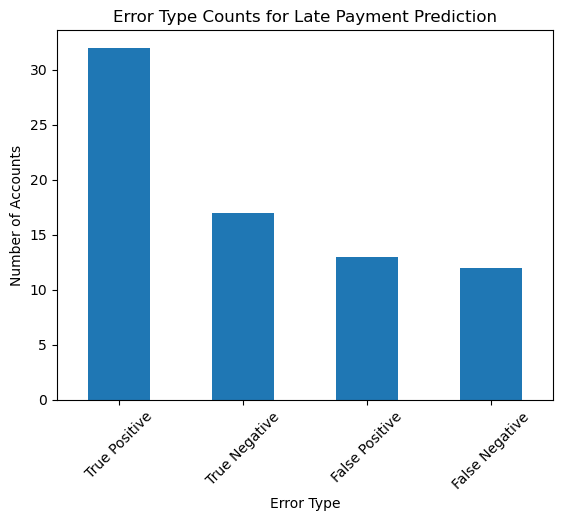

In [30]:
import matplotlib.pyplot as plt

error_counts.plot(
    x="Error Type",
    y="Count",
    kind="bar",
    legend=False
)

plt.title("Error Type Counts for Late Payment Prediction")

plt.xlabel("Error Type")

plt.ylabel("Number of Accounts")

plt.xticks(rotation=45)

plt.show()

This bar chart shows the number of accounts in each prediction category. It helps us visually compare the model's correct and incorrect predictions for late payment prediction.

##### Main Observation

The highest bar belongs to True Positive, with 32 accounts. This means the model correctly predicted that these customers would make a late payment, and they actually made a late payment.
The second highest bar is True Negative, with 17 accounts. This shows that the model correctly identified 17 customers who paid on time.
The model also produced 13 False Positive predictions. These are customers who were predicted to make a late payment but actually paid on time.
The smallest bar is False Negative, with 12 accounts. These are customers who actually made a late payment, but the model incorrectly predicted that they would pay on time.

#### Business Interpretation

The large number of True Positive predictions is a positive result because it shows that the model successfully identified many customers who were at risk of making late payments. This allows the utility company to take proactive actions such as sending payment reminders or offering payment assistance.
However, the model also produced 13 False Positive predictions. This means the company may send unnecessary reminders or warning notices to customers who would have paid on time. These actions can increase operational costs and may reduce customer satisfaction.
The model also produced 12 False Negative predictions. These are important because the company failed to identify some customers who actually made late payments. As a result, the company may miss opportunities to prevent late payments, which could lead to delayed revenue collection and increased financial risk.
Overall, the model generates more correct predictions (True Positives and True Negatives) than incorrect predictions (False Positives and False Negatives), suggesting that it is reasonably effective at identifying customers who are likely to make late payments.

## Task 9: Cross-Validation

In [31]:
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

cv_results = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Accuracy": cv_scores
})

cv_results

,Fold,Accuracy
0,Fold 1,0.689189
1,Fold 2,0.621622
2,Fold 3,0.729730
3,Fold 4,0.702703
4,Fold 5,0.756757


In [32]:
mean_cv_accuracy = cv_scores.mean()

std_cv_accuracy = cv_scores.std()

cv_summary = pd.DataFrame({
    "Metric": ["Mean Cross-Validation Accuracy", "Standard Deviation"],
    "Value": [mean_cv_accuracy, std_cv_accuracy]
})

cv_summary

,Metric,Value
0,Mean Cross-Validation Accuracy,0.700000
1,Standard Deviation,0.045547


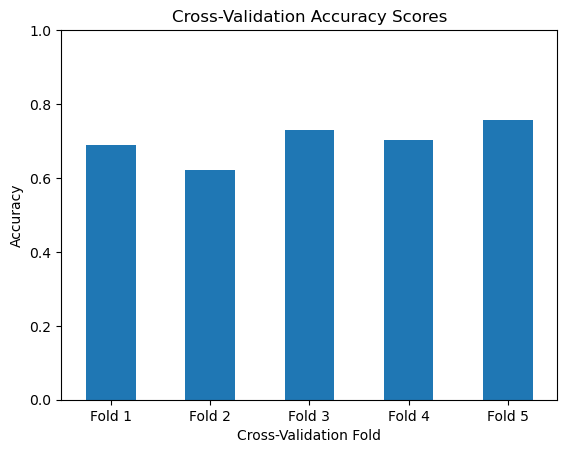

In [33]:
import matplotlib.pyplot as plt

cv_results.plot(
    x="Fold",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Cross-Validation Accuracy Scores")

plt.xlabel("Cross-Validation Fold")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

This bar chart shows the accuracy score achieved in each cross-validation fold. It helps us evaluate whether the model performs consistently across different subsets of the dataset.

#### Main Observation

The highest accuracy score was achieved in Fold 5, with an accuracy of 75.7%.
The lowest accuracy score was achieved in Fold 2, with an accuracy of 62.2%.
The remaining folds produced accuracy scores between 68.9% and 73.0%, indicating that the model performs at a similar level across most folds.
The difference between the highest and lowest accuracy scores is approximately 13.5 percentage points, which is relatively small and suggests that the model's performance does not vary dramatically between folds.

#### Stability Interpretation

Overall, the model appears to have reasonably stable performance across different folds. Although there are some differences in accuracy from one fold to another, all five folds achieved accuracy scores above 60%.

The accuracy scores are:

* Fold 1: 68.9%
* Fold 2: 62.2%
* Fold 3: 73.0%
* Fold 4: 70.3%
* Fold 5: 75.7%

These results indicate that the model can maintain a similar level of predictive performance when trained and tested on different subsets of the data.

#### Business Interpretation

The relatively consistent accuracy scores suggest that the model is reliable for predicting late payments and is not heavily dependent on a particular subset of customers. This is important because the utility company wants a model that performs consistently across different customer groups and time periods.
Since the model shows similar performance across all five folds, the cross-validation results provide evidence that the model is reasonably stable and is likely to generalize well to new customer data.

## Task 10: Overfitting and Underfitting Analysis

In [34]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

y = df["late_payment_next_month"]

X = df.drop(columns=["account_id", "late_payment_next_month"])

X = X.drop(columns=["gender", "age_group", "region"])

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)

overfitting_check = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [train_accuracy, test_accuracy]
})

overfitting_check

,Dataset,Accuracy
0,Training Data,0.827703
1,Testing Data,0.662162


In [35]:
from sklearn.tree import DecisionTreeClassifier

depth_results = []

for depth in range(1, 11):
    
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    temp_model.fit(X_train, y_train)
    
    train_pred = temp_model.predict(X_train)
    
    test_pred = temp_model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    
    test_acc = accuracy_score(y_test, test_pred)
    
    depth_results.append([depth, train_acc, test_acc])

depth_results_df = pd.DataFrame(
    depth_results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.652027,0.594595
1,2,0.736486,0.716216
2,3,0.793919,0.689189
3,4,0.827703,0.662162
4,5,0.858108,0.662162
5,6,0.902027,0.635135
6,7,0.929054,0.662162
7,8,0.962838,0.689189
8,9,0.979730,0.608108
9,10,0.983108,0.648649


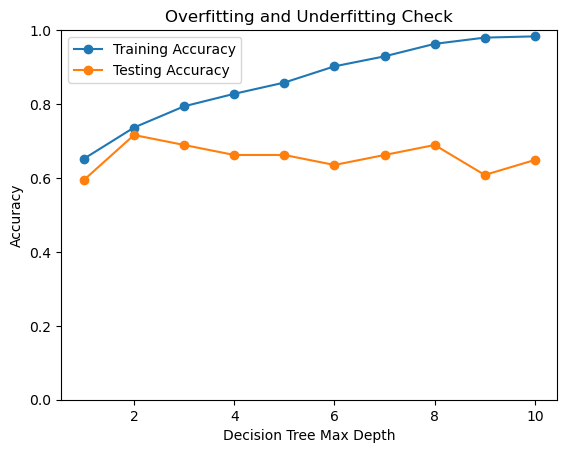

In [36]:
import matplotlib.pyplot as plt

plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.title("Overfitting and Underfitting Check")

plt.xlabel("Decision Tree Max Depth")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.legend()

plt.show()

This chart compares the training accuracy and testing accuracy for Decision Tree models with different maximum tree depths. It helps us determine whether the model is underfitting or overfitting.

#### Main Observation

When the maximum depth is small (Depth 1 and Depth 2), the training accuracy and testing accuracy are relatively close. For example, at Depth 2, the training accuracy is 73.6% and the testing accuracy is 71.6%. This indicates that the model is learning useful patterns and generalizing well to new data.
As the maximum depth increases, the training accuracy continues to improve. At Depth 10, the training accuracy reaches 98.3%. However, the testing accuracy does not improve and remains around 60% to 69%.
The gap between training accuracy and testing accuracy becomes much larger at higher depths. For example:

* Depth 2: Training = 73.6%, Testing = 71.6%
* Depth 8: Training = 96.3%, Testing = 68.9%
* Depth 10: Training = 98.3%, Testing = 64.9%

#### Overfitting and Underfitting Interpretation

The model shows underfitting at Depth 1 because both the training accuracy (65.2%) and testing accuracy (59.5%) are relatively low. This suggests that the model is too simple and cannot fully capture the patterns in the data.
The model performs best around Depth 2, where the training and testing accuracies are both relatively high and very close to each other. This indicates a good balance between learning from the training data and generalizing to new data.
The model shows clear signs of overfitting at higher depths (Depth 6 to Depth 10). As the tree becomes more complex, the training accuracy increases significantly, but the testing accuracy does not improve and even decreases in some cases. This means the model is memorizing the training data rather than learning patterns that generalize well to unseen customers.

Overall, the model shows evidence of overfitting at larger tree depths. A maximum depth of 2 appears to provide the best balance between training performance and testing performance. Therefore, a simpler Decision Tree model is likely to generalize better for predicting late payments in this dataset.

## Task 11: Feature Importance

In [37]:
feature_importance_values = model.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance_values
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
4,previous_late_payments,0.346518
1,monthly_bill_amount,0.299288
15,autopay_enabled_Yes,0.170446
5,support_calls_last_6m,0.078701
3,months_as_customer,0.067321
6,income_estimate,0.037726
0,customer_age,0.000000
11,plan_type_Variable,0.000000
14,payment_method_Debit,0.000000
13,payment_method_Credit Card,0.000000


In [38]:
top_features = feature_importance_df.head(10)

top_features

,Feature,Importance
4,previous_late_payments,0.346518
1,monthly_bill_amount,0.299288
15,autopay_enabled_Yes,0.170446
5,support_calls_last_6m,0.078701
3,months_as_customer,0.067321
6,income_estimate,0.037726
0,customer_age,0.000000
11,plan_type_Variable,0.000000
14,payment_method_Debit,0.000000
13,payment_method_Credit Card,0.000000


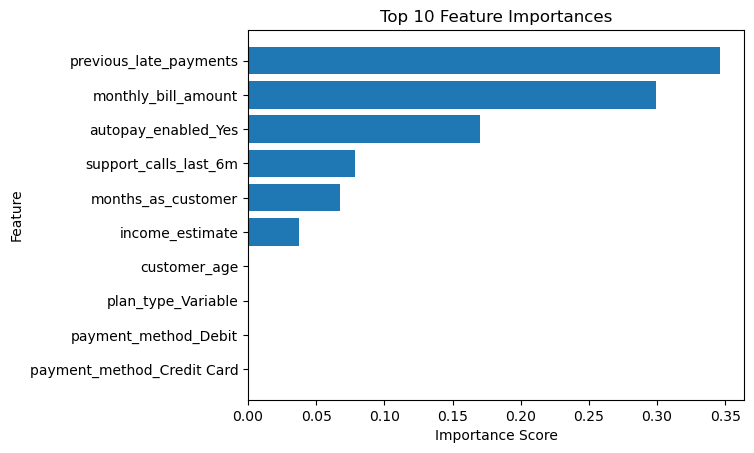

In [39]:
import matplotlib.pyplot as plt

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

This feature importance chart shows which variables have the greatest influence on the Decision Tree model when predicting whether an account will make a late payment. Features with higher importance scores contribute more to the model's decision-making process.

#### Main Observation

The most important feature is previous_late_payments, with an importance score of approximately 0.347. This means that a customer's history of late payments is the strongest predictor of whether they will make a late payment in the future.
The second most important feature is monthly_bill_amount, with an importance score of approximately 0.299. Customers with larger monthly bills may be more likely to experience payment difficulties, making this an important factor in the prediction.
The third most important feature is autopay_enabled_Yes, with an importance score of approximately 0.170. Whether a customer has automatic payments enabled appears to influence the likelihood of late payment.

#### Other features with some predictive value include:

* support_calls_last_6m (0.079)
* months_as_customer (0.067)
* income_estimate (0.038)

Several features, such as customer_age, plan_type_Variable, and some payment method variables, have importance scores close to zero. This indicates that they contributed very little to the model's decisions.

#### Business Interpretation

The importance of previous_late_payments suggests that customers who have missed payments in the past are more likely to make late payments again in the future. This information can help the company identify higher-risk customers and provide early reminders or payment assistance.
The importance of monthly_bill_amount indicates that customers with higher bills may face greater financial pressure, increasing the risk of late payment. The business could consider flexible payment options or installment plans for these customers.
The importance of autopay_enabled_Yes suggests that automatic payment enrollment is related to payment behavior. Encouraging customers to use automatic payments may help reduce the number of late payments.

#### Important Limitation

Feature importance shows which variables are useful for making predictions, but it does not prove cause and effect. For example, although previous late payments are strongly associated with future late payments, this does not mean that previous late payments directly cause future late payments. Other factors, such as financial circumstances or customer behavior, may also influence the outcome.
Therefore, feature importance should be used to understand model behavior and identify important patterns, but it should not be interpreted as proof that one variable causes another.

## Task 12: SHAP Explanation

In [40]:
!pip install shap

In [41]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [42]:
!which python

/opt/miniconda3/bin/python


In [43]:
!pip show shap

Name: shap
Version: 0.52.0
Summary: A unified approach to explain the output of any machine learning model.
Home-page: 
Author: 
Author-email: Scott Lundberg <slund1@cs.washington.edu>
License: MIT License
Location: /opt/miniconda3/lib/python3.13/site-packages
Requires: cloudpickle, llvmlite, numba, numpy, packaging, pandas, scikit-learn, scipy, slicer, tqdm
Required-by: 


In [44]:
import sys

!{sys.executable} -m pip install shap

  Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl (490 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]


In [46]:
import shap

import matplotlib.pyplot as plt

shap.initjs()

In [47]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

type(shap_values)

numpy.ndarray

In [48]:
if isinstance(shap_values, list):

    shap_values_class1 = shap_values[1]

    base_value_class1 = explainer.expected_value[1]

else:
    
    shap_values_class1 = shap_values[:, :, 1]

    base_value_class1 = explainer.expected_value[1]

shap_values_class1.shape

(74, 17)

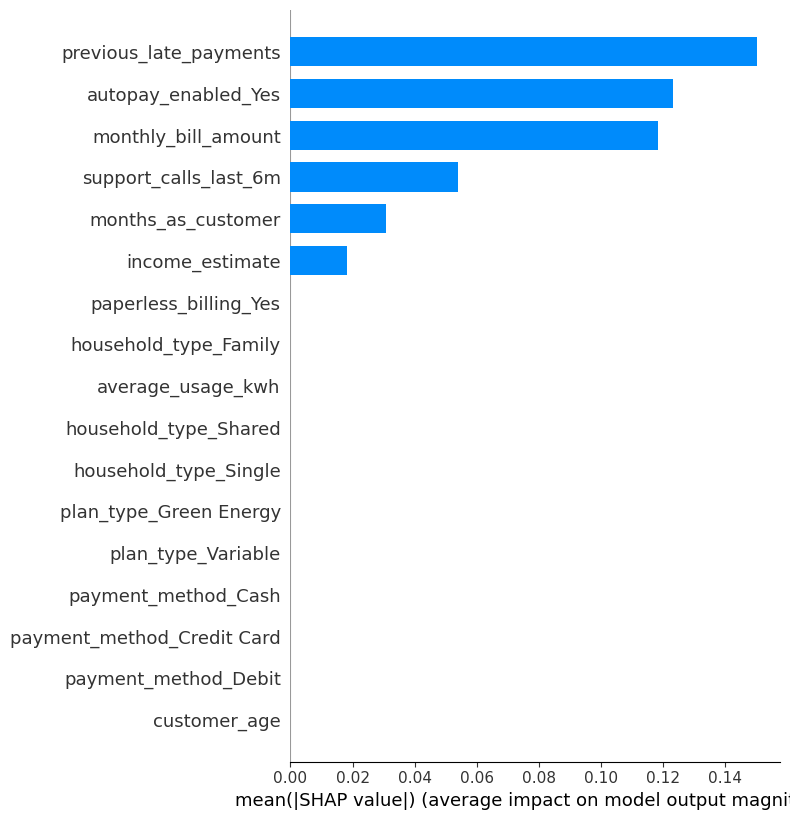

In [49]:
shap.summary_plot(
    shap_values_class1,
    X_test,
    plot_type="bar"
)

In [50]:
customer_index = 0

customer_data = X_test.iloc[customer_index]

customer_shap_values = shap_values_class1[customer_index]

customer_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": customer_data.values,
    "SHAP Value": customer_shap_values
})

customer_explanation["Absolute SHAP Value"] = customer_explanation["SHAP Value"].abs()

customer_explanation = customer_explanation.sort_values(
    by="Absolute SHAP Value",
    ascending=False
)

customer_explanation.head(10)

,Feature,Feature Value,SHAP Value,Absolute SHAP Value
5,support_calls_last_6m,8,0.135739,0.135739
15,autopay_enabled_Yes,False,0.072054,0.072054
1,monthly_bill_amount,229.13,-0.031092,0.031092
3,months_as_customer,11,0.028976,0.028976
6,income_estimate,113107.0,0.004553,0.004553
4,previous_late_payments,2,0.001933,0.001933
0,customer_age,42,0.000000,0.000000
11,plan_type_Variable,False,0.000000,0.000000
14,payment_method_Debit,True,0.000000,0.000000
13,payment_method_Credit Card,False,0.000000,0.000000


### SHAP Explanation for One Individual Record

SHAP (SHapley Additive exPlanations) helps explain why the model made a specific prediction for an individual account. Positive SHAP values increase the likelihood of predicting a late payment, while negative SHAP values decrease that likelihood.

For this account, the most influential feature is support_calls_last_6m, with a SHAP value of 0.135739. This positive value indicates that a high number of support calls increased the model's prediction that the customer may make a late payment.

The second most important feature is autopay_enabled_Yes, with a SHAP value of 0.072054. This feature also contributed positively to the prediction.

On the other hand, monthly_bill_amount has a SHAP value of -0.031092, meaning it reduced the likelihood of the model predicting a late payment.

Other features such as months_as_customer (0.028976), income_estimate (0.004553), and previous_late_payments (0.001933) had smaller positive impacts on the prediction.

Several features, including customer_age, plan_type_Variable, payment_method_Debit, and payment_method_Credit Card, have SHAP values of zero, indicating that they did not influence this specific prediction.

Overall, the model's prediction for this account was mainly driven by the customer's high number of support calls and the autopay setting. These factors had the strongest influence on the model's decision, while monthly bill amount slightly reduced the predicted risk of late payment.


### Interpretation of How Important Features Affect the Prediction

The feature support_calls_last_6m has the largest positive SHAP value (0.135739), meaning it had the strongest impact on increasing the predicted likelihood of a late payment. This suggests that customers who contact support more frequently may have billing issues, service concerns, or financial difficulties that are associated with a higher risk of late payment.

The feature autopay_enabled_Yes also contributed positively to the prediction with a SHAP value of 0.072054. For this specific account, the model learned a pattern that associates this feature with a higher probability of late payment. However, this relationship reflects patterns in the data and should not be interpreted as a direct cause.

In contrast, monthly_bill_amount has a negative SHAP value (-0.031092), meaning it reduced the predicted likelihood of late payment. For this account, the customer's bill amount contributed to making the model less confident that a late payment would occur.

The feature months_as_customer has a positive SHAP value (0.028976), indicating that the customer's length of relationship with the company slightly increased the predicted risk of late payment.

Other features such as income_estimate and previous_late_payments had relatively small positive effects on the prediction, while features such as customer_age, plan_type_Variable, payment_method_Debit, and payment_method_Credit Card had no meaningful impact on this specific prediction because their SHAP values were zero.

Overall, the prediction was mainly influenced by the high number of support calls and the autopay setting, while the monthly bill amount slightly reduced the predicted risk of late payment. These SHAP values help explain the model's decision for this individual account by showing which features contributed most strongly to the prediction.


In [51]:
customer_index = 0

account_id = df.loc[y_test.index[customer_index], "account_id"]

actual_value = y_test.iloc[customer_index]

predicted_value = y_test_pred[customer_index]

single_account_result = pd.DataFrame({
    "Account ID": [account_id],
    "Actual Late Payment": [actual_value],
    "Predicted Late Payment": [predicted_value]
})

single_account_result

,Account ID,Actual Late Payment,Predicted Late Payment
0,U0179,1,1


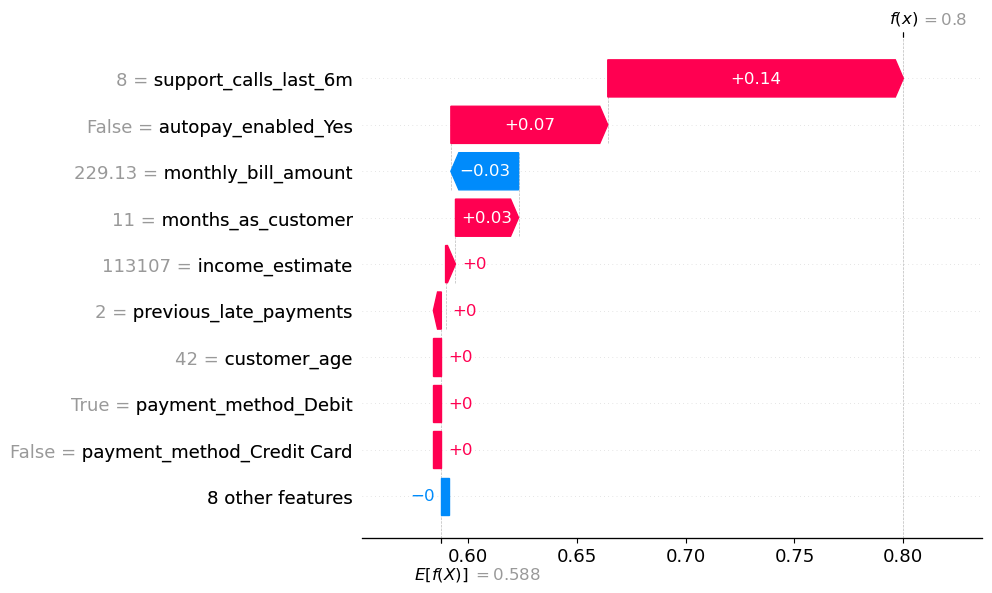

In [53]:
single_customer_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=base_value_class1,
    data=customer_data,
    feature_names=X_test.columns
)

shap.plots.waterfall(single_customer_explanation)

### How SHAP Helps Us Understand the Model Beyond Basic Feature Importance

Basic feature importance shows which features are generally important across the entire dataset. It provides a global view of the model by ranking features according to their overall contribution to predictions.

However, SHAP provides a much deeper level of explanation. SHAP not only identifies which features are important, but also explains how each feature affects an individual prediction. It shows whether a feature increases or decreases the predicted likelihood of a late payment and measures the size of that impact.

For example, the feature importance chart shows that previous_late_payments and monthly_bill_amount are among the most important features overall. However, SHAP reveals how these features influenced a specific account. A feature that is highly important overall may have little impact on one particular prediction, while another feature may play a larger role for that individual customer.

SHAP also provides both the direction and magnitude of each feature's effect. Positive SHAP values increase the prediction toward late payment, while negative SHAP values decrease it. Traditional feature importance scores do not provide this information.

Therefore, SHAP improves model transparency by helping us understand why the model made a specific prediction for a specific account. This makes the model easier to interpret, explain, and trust in real business situations. However, SHAP explains how the model uses features to make predictions and does not prove that those features directly cause late payments.


## Task 13: LIME Explanation


In [54]:
!pip install lime

  Installing build dependencies ... one
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 20.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 33.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 34.3 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.4 MB/s  0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=e16a4961ffada504280c9d55334ff54353e8ca4fe0174cef1efc905cd10e1cab
  Stored in directory: /Users/trangnhungnguyen/Lib

In [58]:
import sys

print(sys.executable)

/opt/anaconda3/bin/python


In [59]:
import sys

!{sys.executable} -m pip install lime

  Using cached lime-0.2.0.1-py3-none-any.whl


In [60]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

In [61]:
X_train_lime = X_train.astype(float)

X_test_lime = X_test.astype(float)

feature_names = X_train_lime.columns.tolist()

class_names = ["On-Time Payment", "Late Payment"]

In [62]:
lime_explainer = LimeTabularExplainer(
    
    training_data=X_train_lime.values,
    
    feature_names=feature_names,
    
    class_names=class_names,

    mode="classification",
 
    discretize_continuous=True
)

In [63]:
customer_index = 0

customer_instance = X_test_lime.iloc[customer_index]

customer_instance

customer_age                      42.00
monthly_bill_amount              229.13
average_usage_kwh               1766.00
months_as_customer                11.00
previous_late_payments             2.00
support_calls_last_6m              8.00
income_estimate               113107.00
household_type_Family              0.00
household_type_Shared              1.00
household_type_Single              0.00
plan_type_Green Energy             0.00
plan_type_Variable                 0.00
payment_method_Cash                0.00
payment_method_Credit Card         0.00
payment_method_Debit               1.00
autopay_enabled_Yes                0.00
paperless_billing_Yes              0.00
Name: 178, dtype: float64

In [75]:
account_instance = X_test_lime.iloc[0]

lime_explanation = lime_explainer.explain_instance(
    data_row=account_instance.values,
    predict_fn=model.predict_proba,
    num_features=10
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [77]:
actual_value = y_test.iloc[customer_index]

predicted_value = model.predict(X_test_lime.iloc[[customer_index]])[0]

predicted_probabilities = model.predict_proba(
    X_test_lime.iloc[[customer_index]]
)[0]

lime_prediction_result = pd.DataFrame({
    "Actual Late Payment": [actual_value],
    "Predicted Late Payment": [predicted_value],
    "Probability of On-Time Payment": [predicted_probabilities[0]],
    "Probability of Late Payment": [predicted_probabilities[1]]
})

lime_prediction_result

,Actual Late Payment,Predicted Late Payment,Probability of On-Time Payment,Probability of Late Payment
0,1,1,0.2,0.8


In [78]:
lime_explanation_table = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature Condition", "Contribution"]
)

# Display the LIME explanation table
lime_explanation_table

,Feature Condition,Contribution
0,previous_late_payments,0.146713
1,monthly_bill_amount,0.109585
2,autopay_enabled_Yes,-0.091285
3,support_calls_last_6m,0.062435
4,income_estimate,-0.017313
5,months_as_customer,-0.012454
6,plan_type_Green Energy,0.005637
7,household_type_Family,0.005101
8,payment_method_Cash,-0.004429
9,household_type_Shared,-0.003024


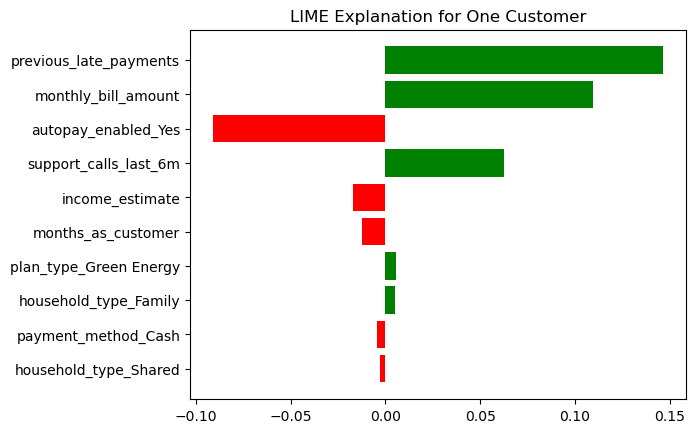

In [79]:
fig = lime_explanation.as_pyplot_figure()

plt.title("LIME Explanation for One Customer")

plt.show()

In [82]:
from IPython.display import display, HTML

lime_html = lime_explanation.as_html()

display(HTML(lime_html))

### Interpretation of Features Supporting the Prediction

The model predicts that this account is likely to make a Late Payment with a probability of approximately 80%, compared to 20% for On-Time Payment.

The most important feature supporting the Late Payment prediction is previous_late_payments. The customer has 2 previous late payments, which strongly increases the likelihood that the customer will make another late payment in the future. This is the largest positive contributor in the LIME explanation.

The second most influential feature is monthly_bill_amount. The customer's monthly bill amount is approximately 229.13, which also increases the probability of a late payment. Higher bill amounts may create greater financial pressure and make it more difficult for customers to pay on time.

Another important feature is support_calls_last_6m, where the customer has made 8 support calls during the last six months. A high number of support calls may indicate service issues, billing concerns, or customer dissatisfaction, which can be associated with payment difficulties.

On the other hand, autopay_enabled_Yes = False contributes toward the On-Time Payment side. This suggests that having automatic payment enabled may reduce the risk of late payments, while not using autopay increases uncertainty in payment behavior.

Additional features such as income_estimate and months_as_customer have smaller effects on the prediction. Their contributions are relatively minor compared with previous late payments and monthly bill amount.

#### Business Interpretation

This explanation suggests that the customer's payment history is the strongest indicator of future payment behavior. Customers with previous late payments, higher monthly bills, and frequent support interactions may require additional monitoring or proactive payment reminders. These insights can help the business identify high-risk accounts and take preventive actions before a late payment occurs.

#### Why LIME is Useful

Unlike global feature importance, LIME explains why the model made a prediction for one specific customer. It shows which features increased or decreased the predicted probability for this individual account. This helps improve transparency and allows businesses to understand the reasoning behind each prediction rather than only knowing which features are important overall.

### Interpretation of Features Working Against the Prediction

Although the model predicts that this account is likely to make a Late Payment, some features work against this prediction and support the On-Time Payment outcome.

The strongest feature working against the Late Payment prediction is autopay_enabled_Yes. The LIME explanation shows that this feature contributes toward the On-Time Payment side. Customers who use automatic payments are generally less likely to miss payment deadlines because payments are processed automatically.

The customer's income_estimate also slightly supports the On-Time Payment prediction. A higher income level may indicate a greater ability to pay bills on time, reducing the risk of late payments.

Additionally, months_as_customer has a small contribution toward On-Time Payment. Customers who have maintained a longer relationship with the company may have more stable payment behavior and greater familiarity with billing processes.

Other features, such as payment_method_Cash and household_type_Shared, have very small contributions and therefore have little influence on the final prediction.

#### Overall Interpretation

While several features support On-Time Payment, their combined influence is weaker than the features supporting Late Payment. In particular, previous_late_payments, monthly_bill_amount, and support_calls_last_6m have a much stronger impact on the model's decision. As a result, the model ultimately predicts that this account is more likely to make a Late Payment, with an estimated probability of approximately 80%.

LIME shows which features influenced this specific prediction, but it does not prove cause and effect. For example, previous late payments are strongly associated with future late payments in the model, but this does not necessarily mean they directly cause future late payments. LIME only explains how the model used the available data to make its prediction.

### How LIME Helps Business Users Understand One Model Prediction

LIME helps business users understand why the model made a prediction for a specific customer or account. Instead of only showing the final prediction, LIME identifies the individual features that influenced the decision and shows whether each feature increased or decreased the predicted risk.

In this example, LIME shows that previous_late_payments, monthly_bill_amount, and support_calls_last_6m were the strongest factors supporting the Late Payment prediction. At the same time, features such as autopay_enabled_Yes and income_estimate worked against the prediction and reduced the risk of late payment.

This information makes the model more transparent and easier to trust because business users can see the reasoning behind the prediction. For example, a collections team can understand why a customer was identified as high risk and can take appropriate actions such as sending payment reminders or offering support.

Unlike global feature importance, which explains the model's behavior across all customers, LIME provides a local explanation for one specific account. This allows business users to understand individual predictions and make more informed decisions based on the factors affecting that particular customer.

It is important to remember that LIME explains how the model made its prediction, but it does not prove that the identified features cause the outcome. It only shows which features had the greatest influence on the model's decision for that specific account.

## Task 14: Fairness and Bias Reflection

In [84]:
y_test_pred = model.predict(X_test)

fairness_data = df.loc[
    y_test.index,
    ["account_id", "gender", "age_group", "region"]
].copy()

fairness_data["Actual Late Payment"] = y_test.values

fairness_data["Predicted Late Payment"] = y_test_pred

fairness_data["Correct Prediction"] = (fairness_data["Actual Late Payment"] == fairness_data["Predicted Late Payment"])

fairness_data.head(10)

,account_id,gender,age_group,region,Actual Late Payment,Predicted Late Payment,Correct Prediction
178,U0179,Female,36-50,North,1,1,True
90,U0091,Female,51+,North,0,0,True
122,U0123,Female,51+,West,1,1,True
308,U0309,Male,36-50,South,0,0,True
265,U0266,Male,26-35,West,1,1,True
295,U0296,Male,51+,East,0,1,False
273,U0274,Male,36-50,South,1,1,True
224,U0225,Female,51+,South,1,1,True
286,U0287,Female,36-50,North,1,0,False
113,U0114,Female,51+,West,0,0,True


In [92]:
def fairness_summary(group_column):
    
    summary = fairness_data.groupby(group_column).agg(
        
        Number_of_Accounts=("account_id", "count"),
        
        Actual_Late_Payment_Rate=("Actual Late Payment", "mean"),

        Predicted_Late_Payment_Rate=("Predicted Late Payment", "mean"),
        
        Accuracy=("Correct Prediction", "mean")
    ).reset_index()
    
    return summary

In [93]:
gender_fairness = fairness_summary("gender")

gender_fairness

,gender,Number_of_Accounts,Actual_Late_Payment_Rate,Predicted_Late_Payment_Rate,Accuracy
0,Female,35,0.571429,0.628571,0.714286
1,Male,39,0.615385,0.589744,0.615385


In [94]:
age_group_fairness = fairness_summary("age_group")

age_group_fairness

,age_group,Number_of_Accounts,Actual_Late_Payment_Rate,Predicted_Late_Payment_Rate,Accuracy
0,18-25,8,0.500000,0.625000,0.625000
1,26-35,13,0.692308,0.846154,0.692308
2,36-50,21,0.714286,0.476190,0.571429
3,51+,32,0.500000,0.593750,0.718750


In [95]:
region_fairness = fairness_summary("region")

region_fairness

,region,Number_of_Accounts,Actual_Late_Payment_Rate,Predicted_Late_Payment_Rate,Accuracy
0,East,12,0.583333,0.583333,0.833333
1,North,21,0.428571,0.619048,0.619048
2,South,22,0.818182,0.636364,0.727273
3,West,19,0.526316,0.578947,0.526316


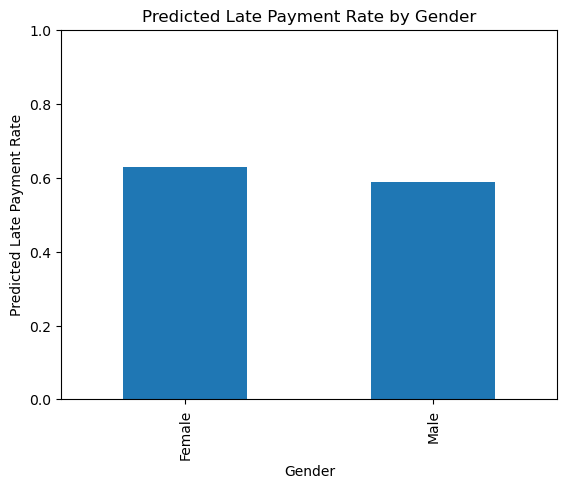

In [96]:
gender_fairness.plot(
    x="gender",
    y="Predicted_Late_Payment_Rate",
    kind="bar",
    legend=False
)

plt.title("Predicted Late Payment Rate by Gender")

plt.xlabel("Gender")

plt.ylabel("Predicted Late Payment Rate")

plt.ylim(0, 1)

plt.show()

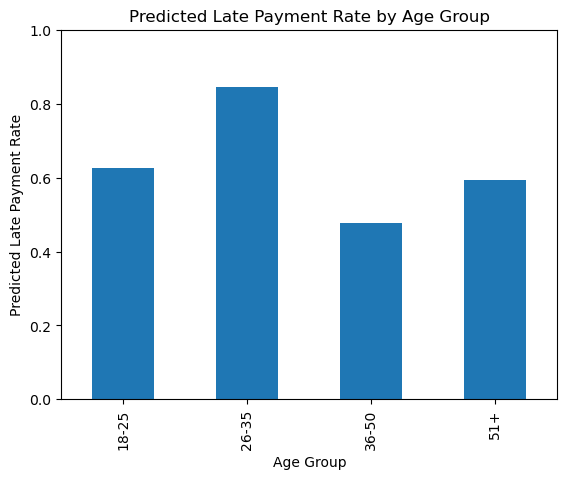

In [97]:
age_group_fairness.plot(
    x="age_group",
    y="Predicted_Late_Payment_Rate",
    kind="bar",
    legend=False
)

plt.title("Predicted Late Payment Rate by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Predicted Late Payment Rate")

plt.ylim(0, 1)

plt.show()

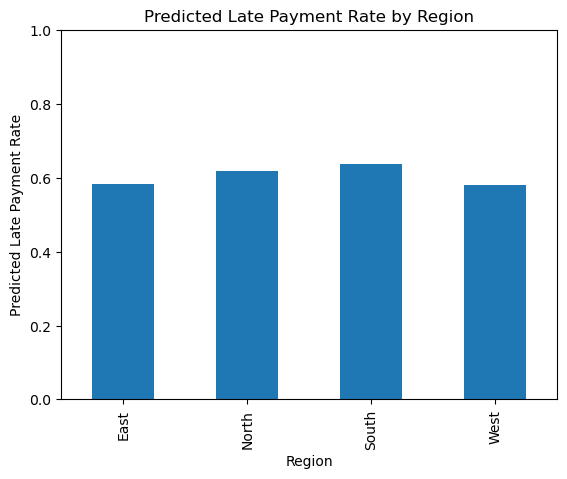

In [98]:
region_fairness.plot(
    x="region",
    y="Predicted_Late_Payment_Rate",
    kind="bar",
    legend=False
)

plt.title("Predicted Late Payment Rate by Region")

plt.xlabel("Region")

plt.ylabel("Predicted Late Payment Rate")

plt.ylim(0, 1)

plt.show()

### Fairness and Bias Reflection

The model does not perform exactly the same across all groups.

For gender, female customers have an accuracy of 71.43% while male customers have an accuracy of 61.54%. This difference suggests that the model is somewhat more reliable for female customers.

For age groups, customers aged 51+ have the highest accuracy (71.88%), while customers aged 36–50 have the lowest accuracy (57.14%). This indicates that model performance varies across age groups.

For regions, accuracy ranges from 52.63% in the West region to 83.33% in the East region. This is a relatively large difference and may indicate that the model learns some groups better than others.

Although these differences do not automatically prove unfairness, they suggest that the model does not behave equally across all customer groups. Before deploying the model in a real business environment, additional fairness testing should be conducted to ensure that certain groups are not systematically disadvantaged.

### Interpretation of Visualizations

The bar charts comparing predicted late payment rates across gender, age groups, and regions help identify differences in model behavior.
The gender chart shows relatively similar predicted rates between males and females. However, the age group chart reveals larger differences, with the 26–35 group receiving substantially higher predicted late payment rates than other groups. The regional chart also shows variation across geographic areas. These visualizations make it easier to identify potential fairness concerns that may not be obvious from accuracy scores alone.

### Conclusion

The fairness analysis suggests that model performance varies somewhat across age groups and regions, while gender differences are relatively small. Although there is no clear evidence of severe discrimination, the differences in prediction rates and accuracy indicate that fairness should be monitored carefully. Regular fairness evaluations can help ensure that automated business decisions remain accurate, transparent, and equitable for all customer groups.



## Task 15: Final Business Interpretation

#### What the Model Predicts

* The model predicts whether a customer is likely to make a late payment based on customer demographics, billing information, payment history, support interactions, and subscription characteristics.

#### Overall Model Performance

* The model achieved moderate performance on the test data. While it successfully identified many late-payment customers, it also produced a noticeable number of incorrect predictions.

#### Most Important Evaluation Metric

* Recall is the most important metric for this business problem because failing to identify customers who may make late payments can lead to financial losses and collection difficulties.

#### Main Error Type

* The most common error type is False Positive. This occurs when the model predicts a late payment but the customer actually pays on time.

#### Business Impact of Errors

* False positives may cause the company to spend unnecessary resources on customer monitoring or collection activities.

* False negatives are also important because customers who are likely to pay late may not receive early intervention.

#### Overfitting or Underfitting Evidence

* The training accuracy is noticeably higher than the testing accuracy, suggesting that the model may be experiencing overfitting. The model learns the training data reasonably well but does not generalize perfectly to unseen customers.

#### Most Important Features

* previous_late_payments
* monthly_bill_amount
* autopay_enabled
* support_calls_last_6m

These variables appear to have the strongest influence on the model predictions. Feature importance helps explain model behavior but does not prove cause-and-effect relationships.

#### SHAP and LIME Insights

* SHAP provided detailed explanations of how individual features pushed predictions toward late payment or on-time payment.

* LIME explained one specific customer prediction and showed which features supported and opposed that prediction.

* Together, SHAP and LIME provide greater transparency than feature importance alone because they explain individual predictions rather than only overall model behavior.

#### Fairness and Bias Concerns

* Fairness analysis showed differences in prediction rates and accuracy across gender, age groups, and regions. Although there is no strong evidence of severe bias, performance differences between groups suggest that fairness should continue to be monitored before deployment.

#### Final Recommendation

* The model demonstrates useful predictive ability and provides interpretable results through feature importance, SHAP, and LIME. However, the model still shows signs of overfitting and uneven performance across some customer groups. Therefore, the model should be considered an early prototype rather than a production-ready business solution.
* Before deployment, the company should improve model performance through hyperparameter tuning, additional feature engineering, cross-validation, and further fairness testing.